In [47]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import gaussian_kde
from itertools import combinations

# get all files in the same datafarme
sectors = {}
for file in os.listdir("/Filepath"):
    sectorname = file.replace(".csv","")
    df = pd.read_csv(os.path.join("/Filepath,file), index_col = 0, parse_dates = True)
    df = df.dropna(axis=1, how="all")
    sectors[sectorname] = df
    
print(sectors)

{'public_utilities':                  ADTN        AEE        AEP        ALE       ATNI        ATO  \
Date                                                                           
2006-01-04  24.972803  30.190048  23.058834  29.197507  13.374221  17.341850   
2006-01-05  24.416165  29.932614  22.929012  29.025982  13.141764  17.283503   
2006-01-06  25.310159  30.371422  23.287567  29.153038  13.135396  17.374264   
2006-01-09  25.546309  30.225153  22.941376  29.222919  12.896570  17.439094   
2006-01-10  26.237889  30.201750  22.947558  29.216566  12.896570  17.354816   
...               ...        ...        ...        ...        ...        ...   
2014-05-05  20.999213  37.030424  47.749692  46.061958  54.868180  47.492710   
2014-05-06  20.740555  36.766051  47.293314  45.597514  54.354147  47.595045   
2014-05-07  21.018373  37.358611  48.322402  46.653897  54.449338  47.995082   
2014-05-08  20.798035  36.738702  47.924984  46.143919  53.430793  46.962429   
2014-05-09  21.3604

In [48]:
sectorreturns = {}
for sector,df in sectors.items():
    logreturns = np.log(df/df.shift(1))
    logreturns = logreturns.dropna()
    sectorreturns[sector] = logreturns.mean(axis=1)
    
sectorreturnsdf = pd.DataFrame(sectorreturns).dropna()
print(sectorreturnsdf)

            public_utilities  miscellaneous  basic_industries  \
Date                                                            
2006-01-05         -0.005309       0.011202          0.006673   
2006-01-06          0.007776       0.016768          0.009497   
2006-01-09          0.000368       0.006656          0.007626   
2006-01-10          0.003651       0.005588          0.007132   
2006-01-11         -0.001801       0.000280         -0.001561   
...                      ...            ...               ...   
2014-04-11         -0.008447      -0.016944         -0.012765   
2014-04-14          0.007299       0.003667          0.006430   
2014-04-15          0.007672       0.003525          0.000076   
2014-04-16          0.006296       0.012506          0.008841   
2014-04-17         -0.004006       0.005588          0.005146   

            consumer_non_durables   finance  health_care  technology  \
Date                                                                   
2006-01-05

In [49]:
sectornames = list(sectorreturnsdf.columns)
print(sectornames)

sectorpairs = list(combinations(sectornames,2))


['public_utilities', 'miscellaneous', 'basic_industries', 'consumer_non_durables', 'finance', 'health_care', 'technology', 'capital_goods', 'consumer_services', 'energy', 'equity_final_finance', 'consumer_durables', 'transportation']


In [50]:
# finding mutual information and correlaion coefficient for each pair
results ={}
for sector1, sector2 in sectorpairs:
    series1 = sectorreturnsdf[sector1].values
    series2 = sectorreturnsdf[sector2].values
    dates = sectorreturnsdf.index
    mi_list = []
    corr_list = []
    time = []
    
# 60 day rolling widnow so measures can capture regime shifts 
    for i in range(60,len(series1)):
        x = series1[i-60:i]
        y = series2[i-60:i]
        
        mi = mutual_info_regression(x.reshape(-1,1),y,discrete_features=False, n_neighbors =3)[0] # built in MI 
        corr = np.corrcoef(x, y)[0, 1]

        mi_list.append(mi)
        corr_list.append(corr)
        time.append(dates[i])

    results[(sector1, sector2)] = pd.DataFrame({
        "Date": time,
        "Mutual_Information": mi_list,
        "Correlation": corr_list})
    
print(results)

{('public_utilities', 'miscellaneous'):            Date  Mutual_Information  Correlation
0    2006-04-03            0.305882     0.629125
1    2006-04-04            0.345603     0.679632
2    2006-04-05            0.332151     0.664836
3    2006-04-06            0.290786     0.654852
4    2006-04-07            0.253658     0.638095
...         ...                 ...          ...
2020 2014-04-11            0.348437     0.749856
2021 2014-04-14            0.380597     0.759997
2022 2014-04-15            0.393123     0.759574
2023 2014-04-16            0.467119     0.758966
2024 2014-04-17            0.423478     0.759992

[2025 rows x 3 columns], ('public_utilities', 'basic_industries'):            Date  Mutual_Information  Correlation
0    2006-04-03            0.380946     0.728696
1    2006-04-04            0.396624     0.746844
2    2006-04-05            0.417965     0.744277
3    2006-04-06            0.443922     0.749480
4    2006-04-07            0.415079     0.737409
...       

In [51]:
print(list(results.keys()))

[('public_utilities', 'miscellaneous'), ('public_utilities', 'basic_industries'), ('public_utilities', 'consumer_non_durables'), ('public_utilities', 'finance'), ('public_utilities', 'health_care'), ('public_utilities', 'technology'), ('public_utilities', 'capital_goods'), ('public_utilities', 'consumer_services'), ('public_utilities', 'energy'), ('public_utilities', 'equity_final_finance'), ('public_utilities', 'consumer_durables'), ('public_utilities', 'transportation'), ('miscellaneous', 'basic_industries'), ('miscellaneous', 'consumer_non_durables'), ('miscellaneous', 'finance'), ('miscellaneous', 'health_care'), ('miscellaneous', 'technology'), ('miscellaneous', 'capital_goods'), ('miscellaneous', 'consumer_services'), ('miscellaneous', 'energy'), ('miscellaneous', 'equity_final_finance'), ('miscellaneous', 'consumer_durables'), ('miscellaneous', 'transportation'), ('basic_industries', 'consumer_non_durables'), ('basic_industries', 'finance'), ('basic_industries', 'health_care'), 

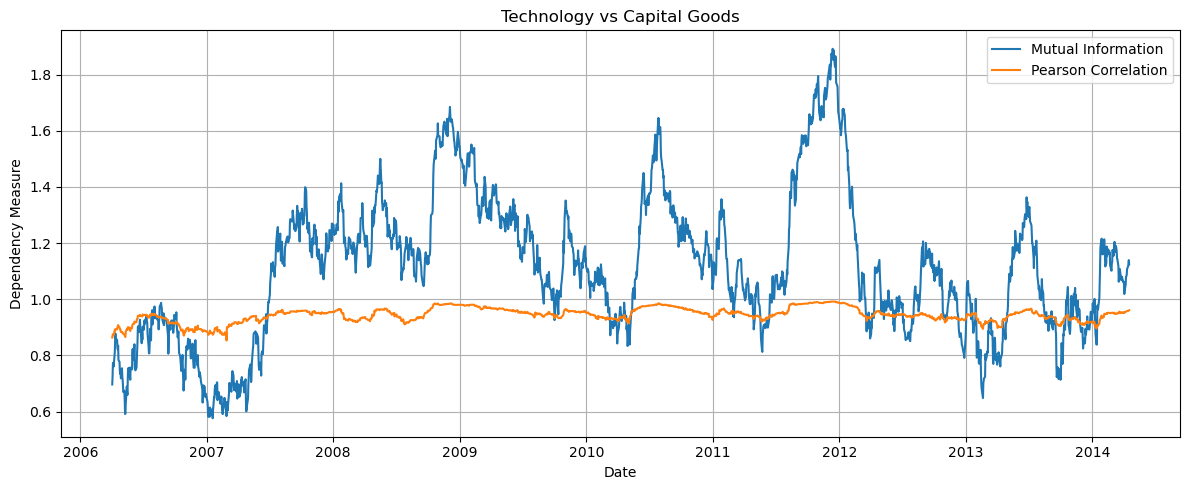

In [80]:
pair = ('technology', 'capital_goods')
df = results[pair]
# plots for sector pair - MI vs correlation
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Mutual_Information"], label="Mutual Information")
plt.plot(df["Date"], df["Correlation"], label="Pearson Correlation")
plt.title("Technology vs Capital Goods")
plt.xlabel("Date")
plt.ylabel("Dependency Measure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


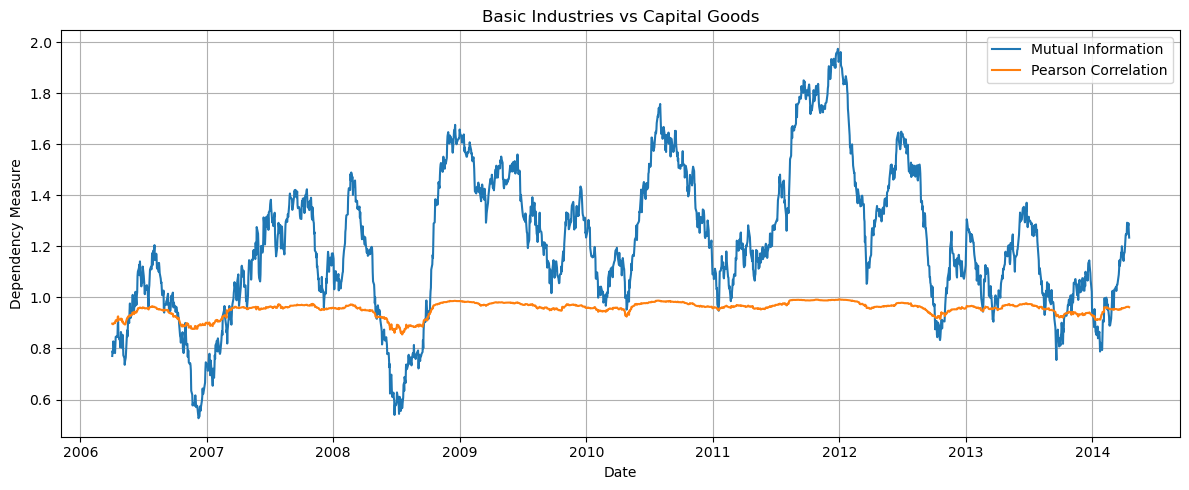

In [54]:
pair = ("basic_industries", "capital_goods")
df = results[pair]


plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Mutual_Information"], label="Mutual Information")
plt.plot(df["Date"], df["Correlation"], label="Pearson Correlation")
plt.title("Basic Industries vs Capital Goods")
plt.xlabel("Date")
plt.ylabel("Dependency Measure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


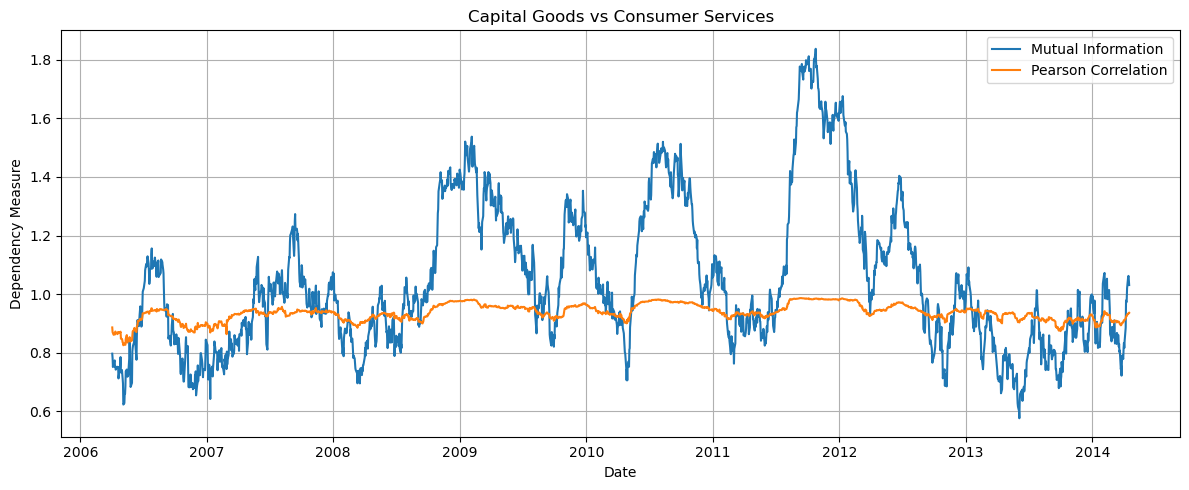

In [55]:
pair = ("capital_goods", "consumer_services")
df = results[pair]


plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Mutual_Information"], label="Mutual Information")
plt.plot(df["Date"], df["Correlation"], label="Pearson Correlation")
plt.title("Capital Goods vs Consumer Services")
plt.xlabel("Date")
plt.ylabel("Dependency Measure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [56]:
quantile_threshold = 0.05  # try 0.01
tail_events = sectorreturnsdf < sectorreturnsdf.quantile(quantile_threshold)
joint_tail_data = []

sector_pairs = list(combinations(sectorreturnsdf.columns, 2))

for sector1, sector2 in sector_pairs:
    # Count days where both sectors had tail events on the same day
    joint_tails = (tail_events[sector1] & tail_events[sector2]).sum()

    key1 = (sector1, sector2)
    key2 = (sector2, sector1)

    if key1 in results:
        dep_df = results[key1]
    elif key2 in results:
        dep_df = results[key2]
    else:
        dep_df = None

    if dep_df is not None:
        avg_mi = dep_df["Mutual_Information"].mean()
        avg_corr = dep_df["Correlation"].mean()

        # Make it a dataframe for ease
        joint_tail_data.append({
            "Sector A": sector1,
            "Sector B": sector2,
            "Avg Mutual Information": avg_mi,
            "Avg Correlation": avg_corr,
            "Joint Tail Events": joint_tails})

joint_tail_df = pd.DataFrame(joint_tail_data)
joint_tail_df = joint_tail_df.sort_values(by="Joint Tail Events", ascending=False)

print(joint_tail_df.head())


                 Sector A              Sector B  Avg Mutual Information  \
47                finance  equity_final_finance                2.124119   
27       basic_industries         capital_goods                1.210025   
57             technology         capital_goods                1.110924   
61             technology     consumer_durables                0.931538   
36  consumer_non_durables         capital_goods                0.955581   

    Avg Correlation  Joint Tail Events  
47         0.996459                100  
27         0.955674                 91  
57         0.944440                 89  
61         0.914195                 87  
36         0.921678                 87  


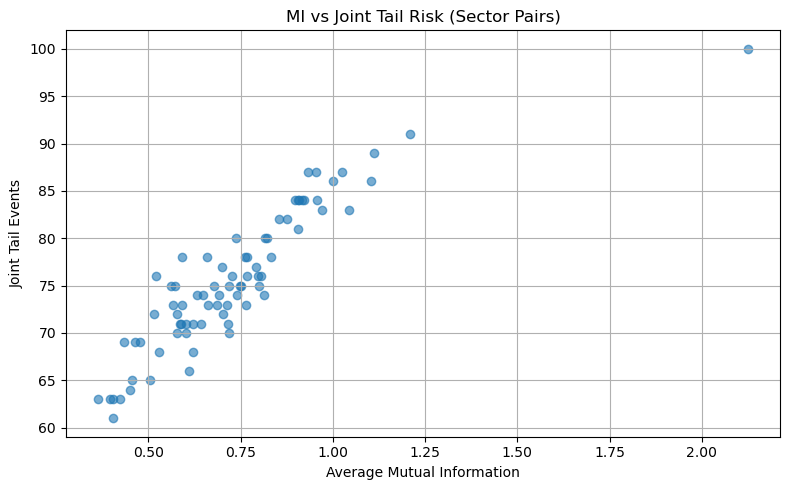

In [85]:
plt.figure(figsize=(8, 5))
plt.scatter(joint_tail_df["Avg Mutual Information"], joint_tail_df["Joint Tail Events"], alpha=0.6)
plt.ylabel("Joint Tail Events")
plt.xlabel("Average Mutual Information")
plt.title("MI vs Joint Tail Risk (Sector Pairs)")
plt.tight_layout()
plt.grid(True)
plt.show()

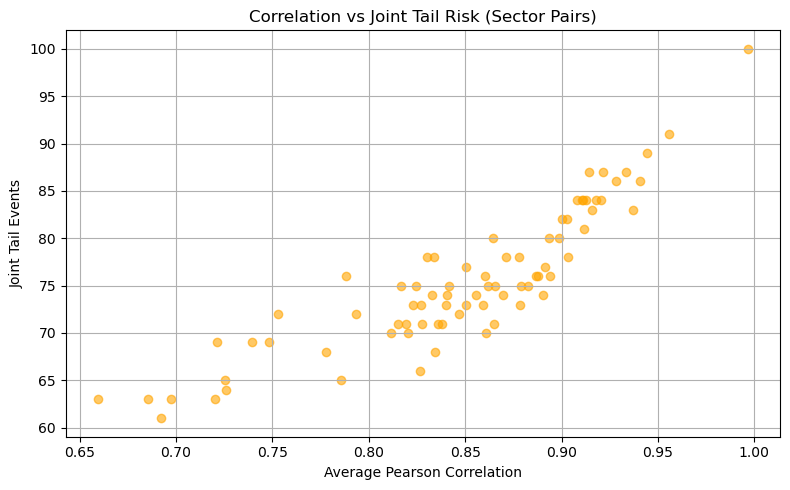

In [83]:
plt.figure(figsize=(8, 5))
plt.scatter(joint_tail_df["Avg Correlation"], joint_tail_df["Joint Tail Events"], color="orange", alpha=0.6)
plt.xlabel("Average Pearson Correlation")
plt.ylabel("Joint Tail Events")
plt.title("Correlation vs Joint Tail Risk (Sector Pairs)")
plt.tight_layout()
plt.grid(True)
plt.show()

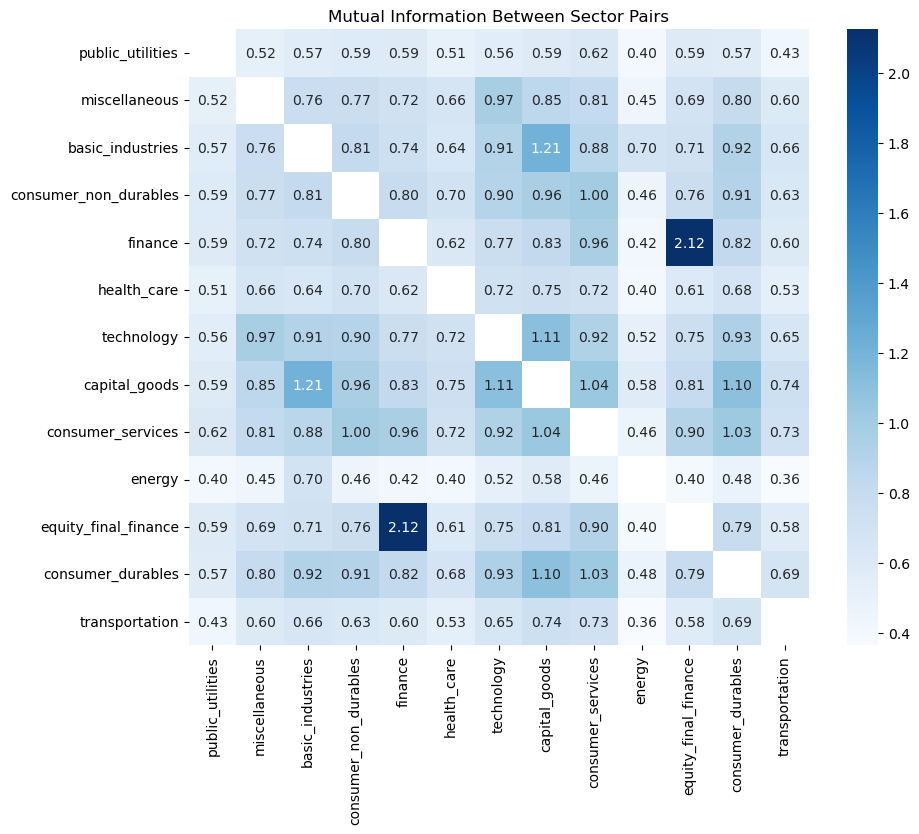

In [86]:
sector_list = sectorreturnsdf.columns.tolist()
mi_matrix = pd.DataFrame(index=sector_list, columns=sector_list, dtype=float)

for (s1, s2), df in results.items():
    avg_mi = df["Mutual_Information"].mean()
    mi_matrix.loc[s1, s2] = avg_mi
    mi_matrix.loc[s2, s1] = avg_mi  # symmetric

plt.figure(figsize=(10, 8))
plt.tight_layout()
sns.heatmap(mi_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Mutual Information Between Sector Pairs")
plt.show()


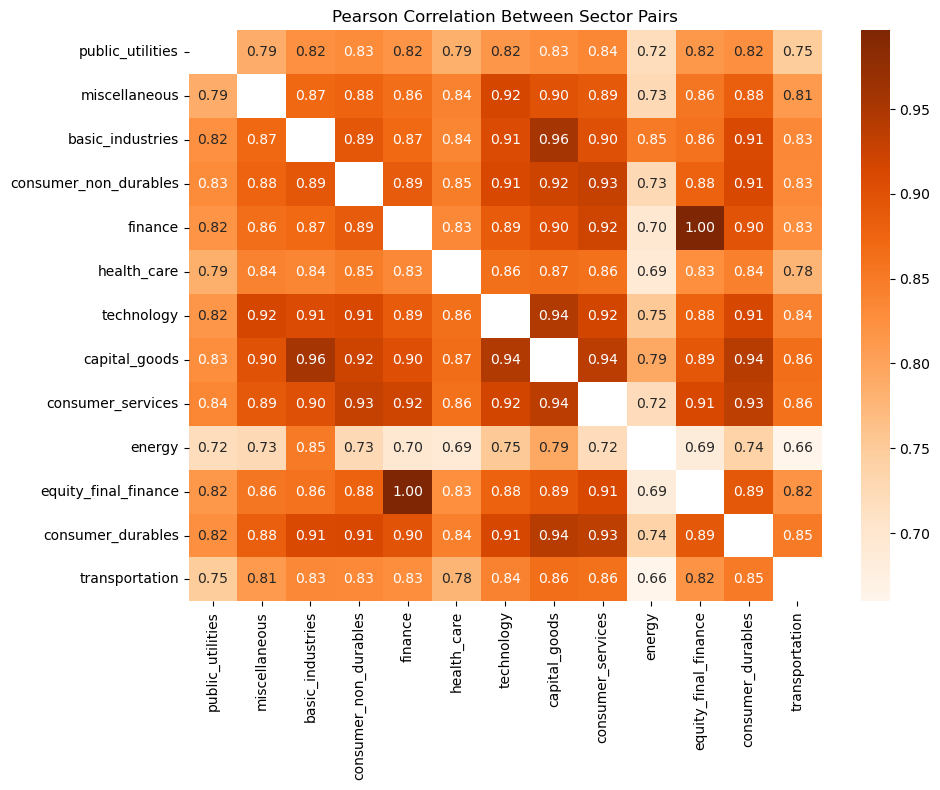

In [60]:
# Same structure, but for correlation
corr_matrix = pd.DataFrame(index=sector_list, columns=sector_list, dtype=float)

for (s1, s2), df in results.items():
    avg_corr = df["Correlation"].mean()
    corr_matrix.loc[s1, s2] = avg_corr
    corr_matrix.loc[s2, s1] = avg_corr  # symmetric

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Oranges', fmt=".2f")
plt.title("Pearson Correlation Between Sector Pairs")
plt.tight_layout()
plt.show()


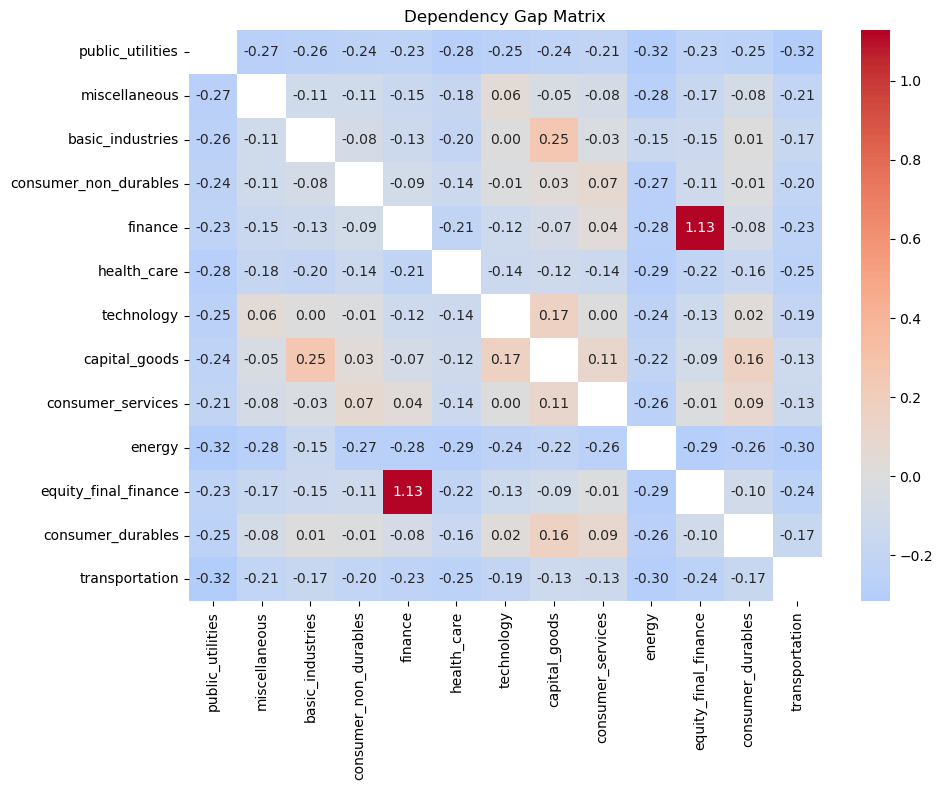

In [77]:
gap_matrix = mi_matrix - corr_matrix

plt.figure(figsize=(10, 8))
sns.heatmap(gap_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Dependency Gap Matrix")
plt.tight_layout()
plt.show()

# USE THIS IN REPORT

In [64]:
top_gap_pairs = []
for i in gap_matrix.index:
    for j in gap_matrix.columns:
        if i != j: # no repeated sector pairs
            gap = gap_matrix.loc[i, j]
            top_gap_pairs.append((i, j, gap))

gap_df = pd.DataFrame(top_gap_pairs, columns=["Sector A", "Sector B", "MI - Corr"])

gap_df["sorted_pair"] = gap_df.apply(lambda row: tuple(sorted([row["Sector A"], row["Sector B"]])), axis=1) # Removes doubled pairs that come up from symmetry
gap_df = gap_df.drop_duplicates(subset="sorted_pair").drop(columns="sorted_pair")

# Sort by gap and show top 3
top_5 = gap_df.sort_values(by="MI - Corr", ascending=False).head(3)
print(top_5)


            Sector A              Sector B  MI - Corr
57           finance  equity_final_finance   1.127660
30  basic_industries         capital_goods   0.254351
78        technology         capital_goods   0.166484


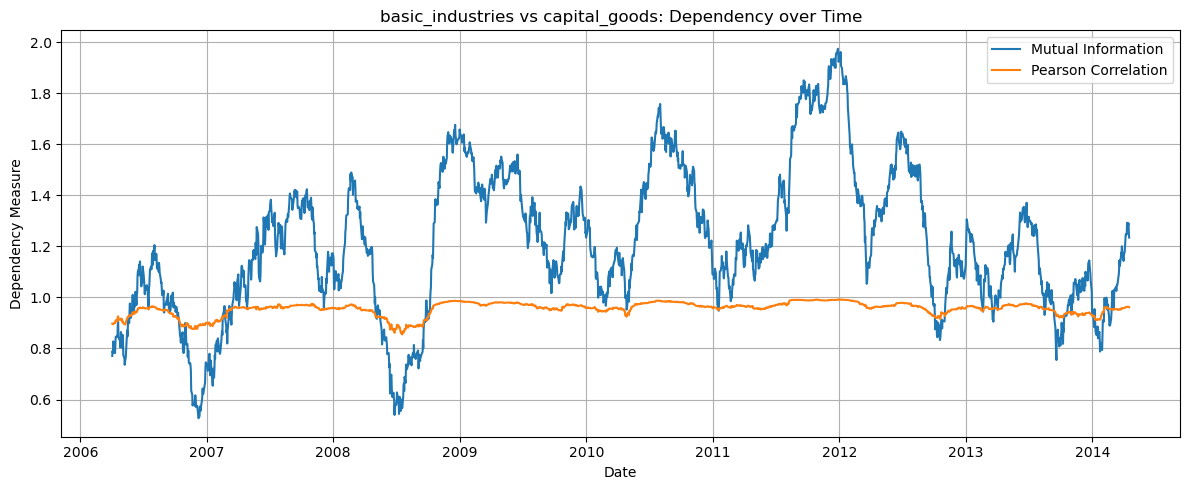

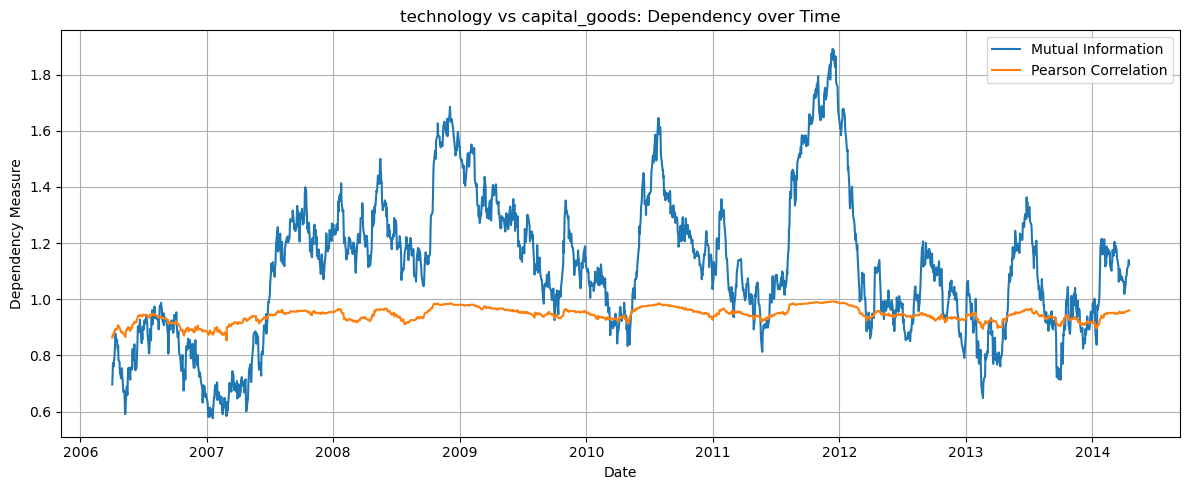

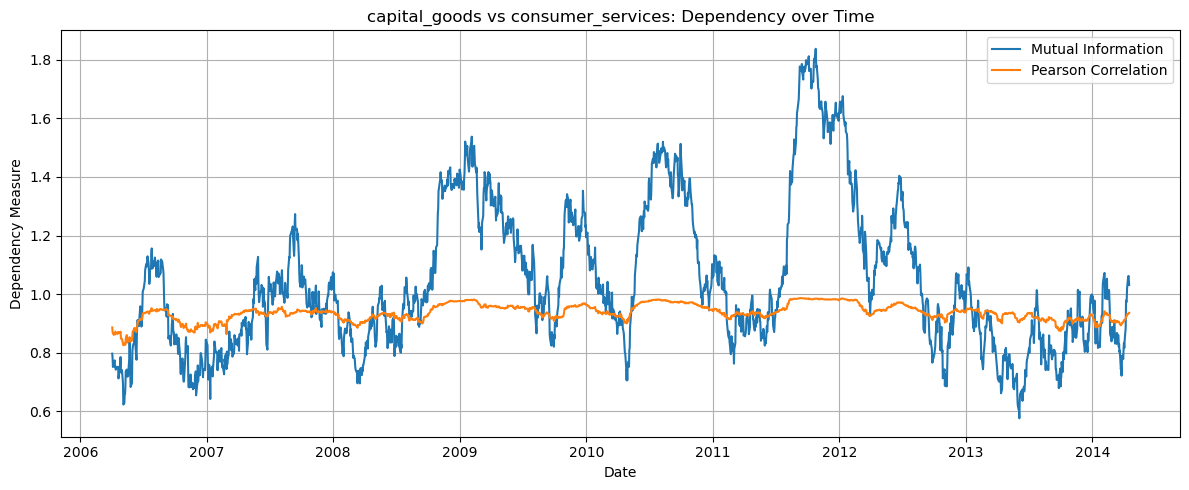

In [65]:
top_pairs = [('basic_industries', 'capital_goods'),('technology', 'capital_goods'),('capital_goods', 'consumer_services')]

for pair in top_pairs:
    if pair in results:
        df_pair = results[pair]
    elif (pair[1], pair[0]) in results:
        df_pair = results[(pair[1], pair[0])]

    # Plot MI and Correlation over time
    plt.figure(figsize=(12, 5))
    plt.plot(df_pair['Date'], df_pair['Mutual_Information'], label='Mutual Information')
    plt.plot(df_pair['Date'], df_pair['Correlation'], label='Pearson Correlation')
    plt.title(f"{pair[0]} vs {pair[1]}: Dependency over Time")
    plt.xlabel('Date')
    plt.ylabel('Dependency Measure')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


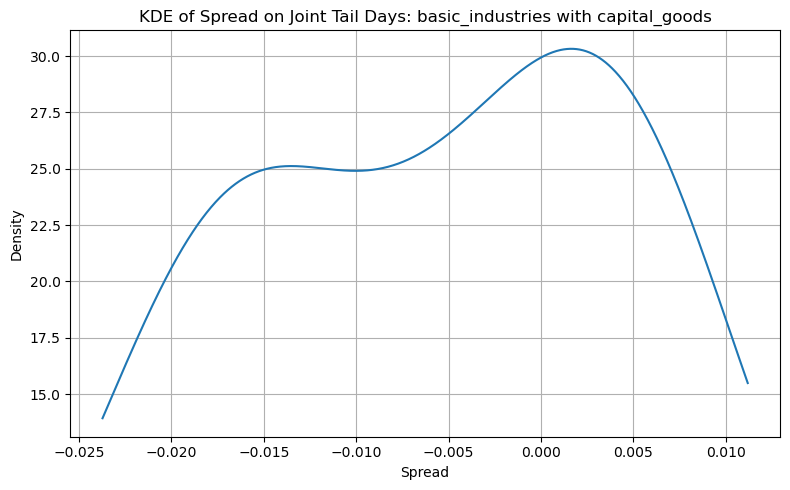

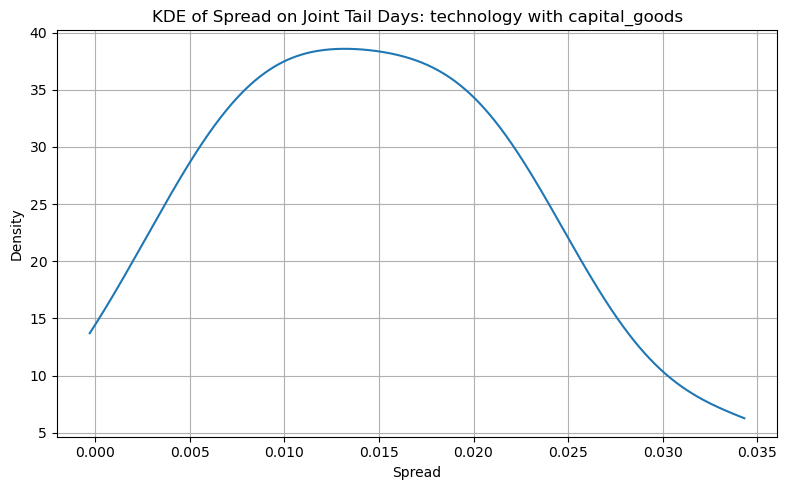

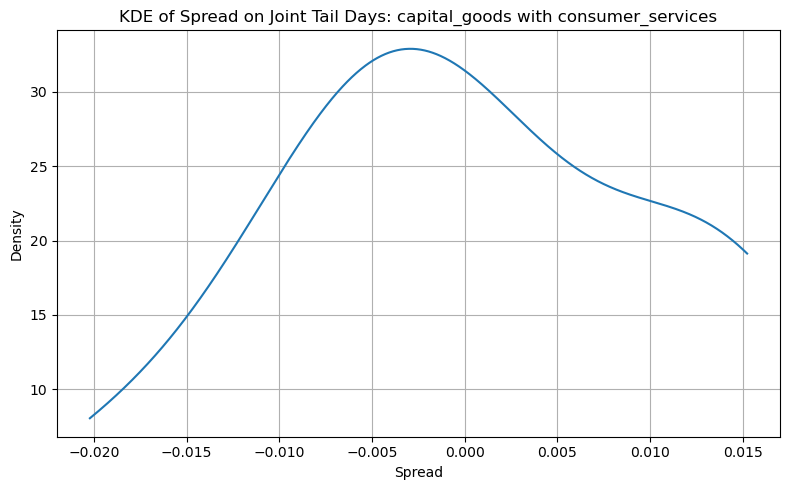

In [66]:
top_pairs = [('basic_industries', 'capital_goods'),('technology', 'capital_goods'),('capital_goods', 'consumer_services')]

# 1% threshold
tail_quantile = 0.01

for pair in top_pairs:
    sector1, sector2 = pair
    
    # Calculate tail thresholds
    threshold1 = sectorreturnsdf[sector1].quantile(tail_quantile)
    threshold2 = sectorreturnsdf[sector2].quantile(tail_quantile)
    
    joint_tail_mask = (sectorreturnsdf[sector1] < threshold1) & (sectorreturnsdf[sector2] < threshold2)
    
    # Get spread on joint tail days
    spread = sectorreturnsdf.loc[joint_tail_mask, sector1] - sectorreturnsdf.loc[joint_tail_mask, sector2]
    
    x_vals = np.linspace(spread.min(), spread.max(),1000) # needed to create even range for smooth curve
    kde = gaussian_kde(spread)
    y_vals = kde(x_vals)
    
    # Plot KDE of spread on tail days
    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, y_vals)
    plt.title(f"KDE of Spread on Joint Tail Days: {sector1} with {sector2}")
    plt.xlabel("Spread")
    plt.ylabel("Density")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [79]:
from scipy.stats import anderson
top_pairs = [ ('technology', 'capital_goods'),('basic_industries', 'capital_goods'),('capital_goods', 'consumer_services')]

tail_quantile = 0.01
ad_results = []

for pair in top_pairs:
    sector1, sector2 = pair

    # thresholds for joint tail
    threshold1 = sectorreturnsdf[sector1].quantile(tail_quantile)
    threshold2 = sectorreturnsdf[sector2].quantile(tail_quantile)
    joint_tail_mask = (sectorreturnsdf[sector1] < threshold1) & (sectorreturnsdf[sector2] < threshold2)
    spread = sectorreturnsdf.loc[joint_tail_mask, sector1] - sectorreturnsdf.loc[joint_tail_mask, sector2]

    result = anderson(spread, dist = 'gumbel_l')
    ad_stat = result.statistic # extract each stat
    sf_level = result.significance_level
    crit_val = result.critical_values
    
    # results in dataframe
    ad_results.append({'pair': pair,'5% Critical Value': crit_val[2],'Passes with 5%sf': ad_stat < crit_val[2]})

ad_results_df = pd.DataFrame(ad_results)
print(ad_results_df)


                                 pair  5% Critical Value  Passes with 5%sf
0         (technology, capital_goods)              0.722              True
1   (basic_industries, capital_goods)              0.723              True
2  (capital_goods, consumer_services)              0.721              True


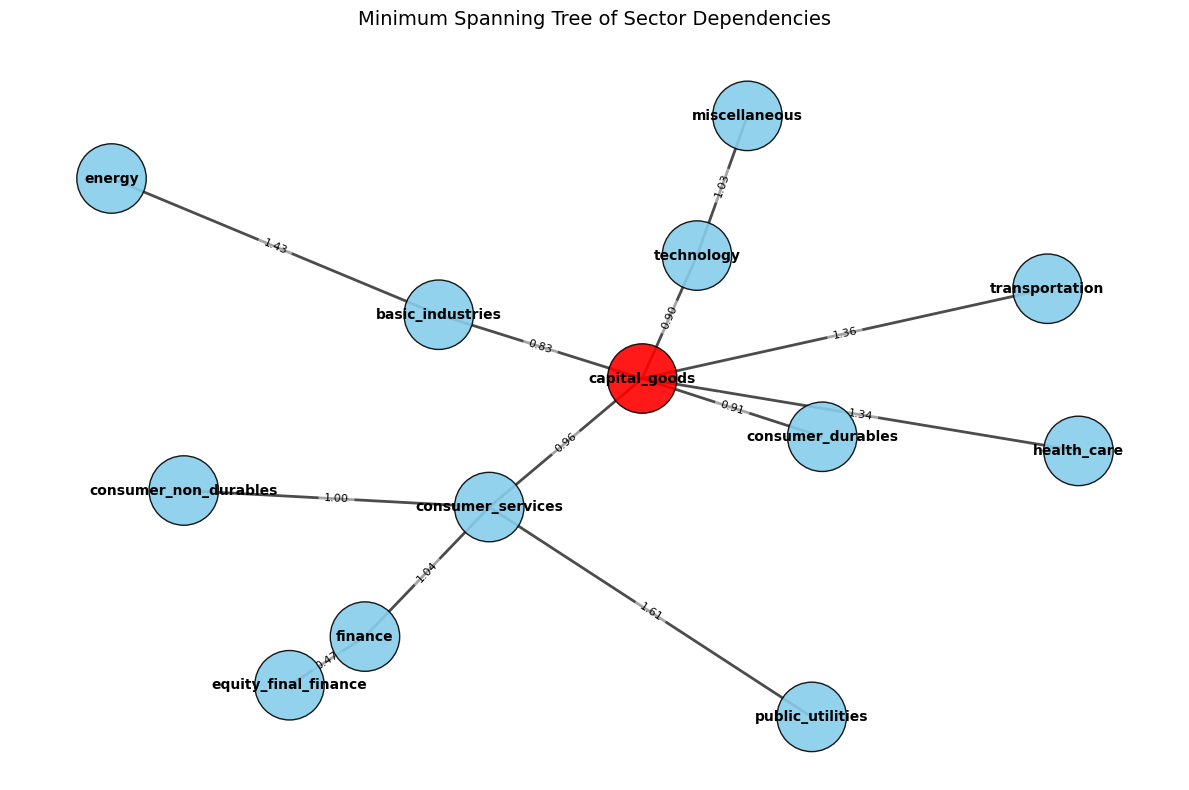

In [76]:
# Finding the MST

import networkx as nx
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

sectors = list(sectorreturnsdf.columns)
mimatrix = pd.DataFrame(0.0, index=sectors, columns=sectors)
for (sector1, sector2), df in results.items():
    avgmi = df["Mutual_Information"].mean()
    mimatrix.loc[sector1, sector2] = avgmi # same as before, checing for rearranged but same pairs
    mimatrix.loc[sector2, sector1] = avgmi

distance = 1 / mimatrix # inverse MI to sort by distance - higher MI means closer to central
distsparse = csr_matrix(distance).toarray()
mstarray = minimum_spanning_tree(distsparse).toarray()


graph = nx.Graph()
for i in range(len(sectors)):
    for j in range(len(sectors)):
        weight = mstarray[i][j]
        if weight > 0:
            graph.add_edge(sectors[i], sectors[j], weight=weight)

plt.figure(figsize=(12,8))
# Kamada Kawai layout (if doesnt work just do the normal one)
nodepos = nx.kamada_kawai_layout(graph, weight='weight')
node_colors = [
    'red' if node == "capital_goods" else 'skyblue' 
    for node in graph.nodes()]

# Nodes

nx.draw_networkx_nodes(graph, nodepos, node_size=2500, node_color=node_colors, alpha=0.9, edgecolors='black', linewidths=1.0)
# Edges
nx.draw_networkx_edges(graph, nodepos, width=2, edge_color='black',alpha=0.7)

# Labels
nx.draw_networkx_labels(graph, nodepos,font_size=10, font_weight='bold')

edge_labels = {(u, v): f"{d['weight']:.2f}" 
    for u, v, d in graph.edges(data=True)}

nx.draw_networkx_edge_labels(graph, nodepos,edge_labels=edge_labels,font_size=8,bbox=dict(alpha=0.5, facecolor='white', edgecolor='none'))

plt.title( "Minimum Spanning Tree of Sector Dependencies", fontsize=14, pad=20 )
plt.axis("off")
plt.tight_layout()